In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import sys
sys.path.insert(0, "../..")
from pipeline import preprocess as canonical_preprocess


In [2]:
df = pd.read_csv("../../data/raw/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(df.shape)

(768, 9)


In [4]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [5]:
# Uses the shared canonical preprocessing (pipeline.py): stratified
# 80/20 split first, then median imputation fit on the training fold only.
X_train, X_test, y_train, y_test = canonical_preprocess("../../data/raw/diabetes.csv")


In [6]:
model = LogisticRegression(max_iter=1000)

In [7]:
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [8]:
y_pred = model.predict(X_test)

In [9]:
y_prob = model.predict_proba(X_test)[:, 1]

In [10]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

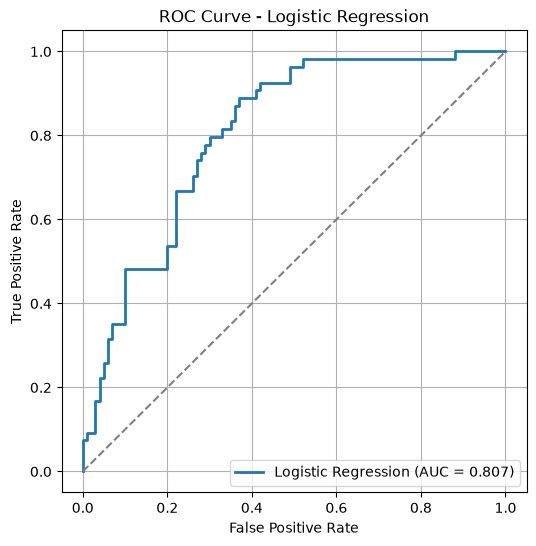

ROC curve saved successfully.


In [11]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

os.makedirs("../../results/roc", exist_ok=True)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend(loc="lower right")
plt.grid(True)

plt.savefig(
    "../../results/roc/roc_logistic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved successfully.")

In [12]:
import pandas as pd

roc_df = pd.DataFrame({
    "FPR": fpr,
    "TPR": tpr
})

import os

os.makedirs("../../results/roc", exist_ok=True)

roc_df.to_csv(
    "../../results/roc/roc_logistic.csv",
    index=False
)

print("ROC data saved successfully.")

ROC data saved successfully.


In [13]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

In [14]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC ROC  :", auc)

Accuracy : 0.7077922077922078
Precision: 0.6046511627906976
Recall   : 0.48148148148148145
F1 Score : 0.5360824742268041
AUC ROC  : 0.8070370370370371


In [15]:
log_path = "../../results/results_log.csv"

new_row = pd.DataFrame({
    "model": ["Logistic Regression"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1": [f1],
    "auc_roc": [auc]
})

try:
    results = pd.read_csv(log_path)
except FileNotFoundError:
    results = pd.DataFrame(columns=["model", "accuracy", "precision", "recall", "f1", "auc_roc"])

if "Logistic Regression" in results["model"].values:
    results.loc[
        results["model"] == "Logistic Regression",
        ["accuracy", "precision", "recall", "f1", "auc_roc"]
    ] = [accuracy, precision, recall, f1, auc]
else:
    results = pd.concat([results, new_row], ignore_index=True)

results.to_csv(log_path, index=False)

print("File Saved Successfully")

results


File Saved Successfully


,model,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,0.707792,0.604651,0.481481,0.536082,0.807037
1,RF,0.766234,0.695652,0.592593,0.640000,0.817870
2,DT,0.785700,0.698100,0.685200,0.691600,0.788700
3,SVM,0.707792,0.604651,0.481481,0.536082,0.816852
4,Static MLP,0.727273,0.630435,0.537037,0.580000,0.840000


In [16]:
pd.read_csv("../../results/results_log.csv")

,model,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,0.707792,0.604651,0.481481,0.536082,0.807037
1,RF,0.766234,0.695652,0.592593,0.640000,0.817870
2,DT,0.785700,0.698100,0.685200,0.691600,0.788700
3,SVM,0.707792,0.604651,0.481481,0.536082,0.816852
4,Static MLP,0.727273,0.630435,0.537037,0.580000,0.840000


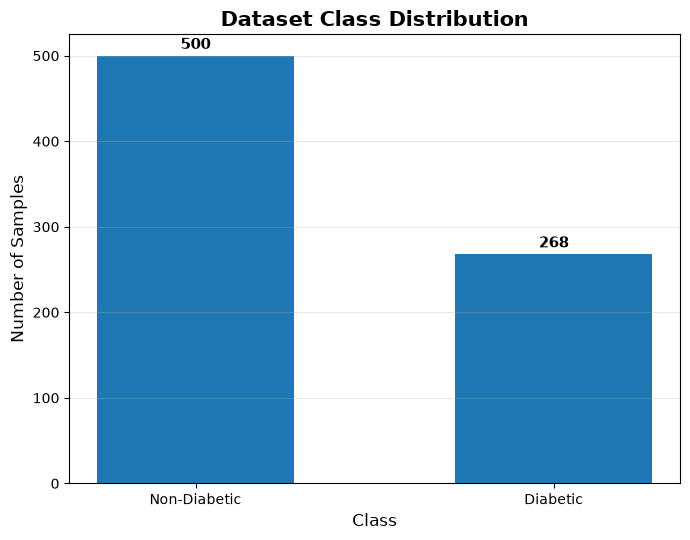

Figure 6 saved successfully.


In [17]:
import matplotlib.pyplot as plt
import os

os.makedirs("../../results/class", exist_ok=True)

counts = df["Outcome"].value_counts().sort_index()

plt.figure(figsize=(7,5.5))

bars = plt.bar(
    ["Non-Diabetic", "Diabetic"],
    counts.values,
    width=0.55
)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+8,
        str(int(h)),
        ha="center",
        fontsize=11,
        weight="bold"
    )

plt.title(
    "Dataset Class Distribution",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../../results/class/dataset_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 6 saved successfully.")